## Imports

In [7]:
import tensorflow as tf
from tensorflow.keras import layers, models, callbacks
import numpy as np
import matplotlib.pyplot as plt
import os

## Utils

In [ ]:
def build_discriminator():
    model = models.Sequential(name="Discriminator")

    model.add(
        layers.Conv2D(
            64, (5, 5), strides=(2, 2), padding="same", input_shape=[28, 28, 1]
        )
    )
    model.add(layers.LeakyReLU())
    model.add(layers.Dropout(0.3))

    model.add(layers.Conv2D(128, (5, 5), strides=(2, 2), padding="same"))
    model.add(layers.LeakyReLU())
    model.add(layers.Dropout(0.3))

    model.add(layers.Flatten())
    model.add(
        layers.Dense(1, activation="sigmoid")
    )
    return model

In [ ]:
def build_generator(latent_dim):
    model = models.Sequential(name="Generator")

    # Base dense layer to process the random noise vector
    model.add(layers.Dense(7 * 7 * 256, use_bias=False, input_shape=(latent_dim,)))
    model.add(layers.BatchNormalization())
    model.add(layers.LeakyReLU())
    model.add(layers.Reshape((7, 7, 256)))

    # Upsample to 7x7
    model.add(
        layers.Conv2DTranspose(
            128, (5, 5), strides=(1, 1), padding="same", use_bias=False
        )
    )
    model.add(layers.BatchNormalization())
    model.add(layers.LeakyReLU())

    # Upsample to 14x14
    model.add(
        layers.Conv2DTranspose(
            64, (5, 5), strides=(2, 2), padding="same", use_bias=False
        )
    )
    model.add(layers.BatchNormalization())
    model.add(layers.LeakyReLU())

    # Final Upsample to 28x28x1
    model.add(
        layers.Conv2DTranspose(
            1, (5, 5), strides=(2, 2), padding="same", use_bias=False, activation="tanh"
        )
    )
    return model

In [ ]:
class DCGAN(models.Model):
    def __init__(self, discriminator, generator, latent_dim):
        super(DCGAN, self).__init__()
        self.discriminator = discriminator
        self.generator = generator
        self.latent_dim = latent_dim

    def compile(self, d_optimizer, g_optimizer, loss_fn):
        super(DCGAN, self).compile()
        self.d_optimizer = d_optimizer
        self.g_optimizer = g_optimizer
        self.loss_fn = loss_fn
        self.d_loss_metric = tf.keras.metrics.Mean(name="d_loss")
        self.g_loss_metric = tf.keras.metrics.Mean(name="g_loss")

    @property
    def metrics(self):
        return [self.d_loss_metric, self.g_loss_metric]

    def train_step(self, real_images):
        batch_size = tf.shape(real_images)[0]

        # Train the Discriminator
        random_latent_vectors = tf.random.normal(shape=(batch_size, self.latent_dim))
        generated_images = self.generator(random_latent_vectors)
        combined_images = tf.concat([generated_images, real_images], axis=0)

        # Labels: 0 for fake, 1 for real
        labels = tf.concat(
            [tf.zeros((batch_size, 1)), tf.ones((batch_size, 1))], axis=0
        )
        # Add slight random noise to labels
        labels += 0.05 * tf.random.uniform(tf.shape(labels))

        with tf.GradientTape() as tape:
            predictions = self.discriminator(combined_images)
            d_loss = self.loss_fn(labels, predictions)

        grads = tape.gradient(d_loss, self.discriminator.trainable_weights)
        self.d_optimizer.apply_gradients(
            zip(grads, self.discriminator.trainable_weights)
        )

        # 2. Train the Generator
        random_latent_vectors = tf.random.normal(shape=(batch_size, self.latent_dim))
        misleading_labels = tf.ones(
            (batch_size, 1)
        )

        with tf.GradientTape() as tape:
            predictions = self.discriminator(self.generator(random_latent_vectors))
            g_loss = self.loss_fn(misleading_labels, predictions)

        grads = tape.gradient(g_loss, self.generator.trainable_weights)
        self.g_optimizer.apply_gradients(zip(grads, self.generator.trainable_weights))

        self.d_loss_metric.update_state(d_loss)
        self.g_loss_metric.update_state(g_loss)
        return {
            "d_loss": self.d_loss_metric.result(),
            "g_loss": self.g_loss_metric.result(),
        }

In [ ]:
def test_and_predict(generator, discriminator, latent_dim, num_images=16):
    print("\nPredictions")
    
    random_latent_vectors = tf.random.normal(shape=(num_images, latent_dim))
    generated_images = generator(random_latent_vectors, training=False)
    discriminator_scores = discriminator(generated_images, training=False)
    
    generated_images = (generated_images + 1.0) / 2.0
    
    fig, axes = plt.subplots(4, 4, figsize=(10, 10))
    fig.suptitle('Generated Images & Discriminator Scores\n(>0.5 = Discriminator Fooled)', fontsize=16)
    
    for i, ax in enumerate(axes.flatten()):
        ax.imshow(generated_images[i, :, :, 0], cmap='gray')
        
        score = discriminator_scores[i][0].numpy()
        
        color = 'green' if score > 0.5 else 'red'
        ax.set_title(f"Score: {score:.3f}", color=color)
        ax.axis('off')
        
    plt.tight_layout()
    plt.subplots_adjust(top=0.90)
    plt.show()

## Dataset

In [ ]:
(X_train, _), (_, _) = tf.keras.datasets.fashion_mnist.load_data()

# Normalize data to the range [-1, 1]
X_train = X_train.astype("float32")
X_train = (X_train - 127.5) / 127.5
X_train = np.expand_dims(X_train, axis=-1)  # Shape becomes (60000, 28, 28, 1)

BATCH_SIZE = 256
LATENT_DIM = 100

dataset = tf.data.Dataset.from_tensor_slices(X_train).shuffle(60000).batch(BATCH_SIZE)

## Training

Epoch 1/30
235/235 ━━━━━━━━━━━━━━━━━━━━ 29s 114ms/step - d_loss: 0.5861 - g_loss: 0.7943
Epoch 2/30
235/235 ━━━━━━━━━━━━━━━━━━━━ 26s 111ms/step - d_loss: 0.6562 - g_loss: 0.7517
Epoch 3/30
235/235 ━━━━━━━━━━━━━━━━━━━━ 26s 112ms/step - d_loss: 0.6493 - g_loss: 0.7552
Epoch 4/30
235/235 ━━━━━━━━━━━━━━━━━━━━ 26s 112ms/step - d_loss: 0.6403 - g_loss: 0.8137
Epoch 5/30
235/235 ━━━━━━━━━━━━━━━━━━━━ 0s 111ms/step - d_loss: 0.6234 - g_loss: 0.8717

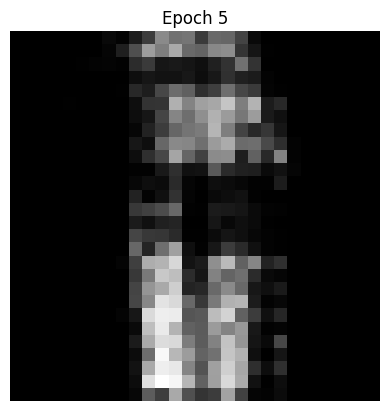

235/235 ━━━━━━━━━━━━━━━━━━━━ 27s 115ms/step - d_loss: 0.6128 - g_loss: 0.8798
Epoch 6/30
235/235 ━━━━━━━━━━━━━━━━━━━━ 26s 112ms/step - d_loss: 0.6099 - g_loss: 0.8691
Epoch 7/30
235/235 ━━━━━━━━━━━━━━━━━━━━ 27s 113ms/step - d_loss: 0.6433 - g_loss: 0.7862
Epoch 8/30
235/235 ━━━━━━━━━━━━━━━━━━━━ 26s 112ms/step - d_loss: 0.6559 - g_loss: 0.7452
Epoch 9/30
235/235 ━━━━━━━━━━━━━━━━━━━━ 26s 112ms/step - d_loss: 0.6589 - g_loss: 0.7305
Epoch 10/30
235/235 ━━━━━━━━━━━━━━━━━━━━ 0s 114ms/step - d_loss: 0.6575 - g_loss: 0.7373

\nSaved generator model at epoch 10


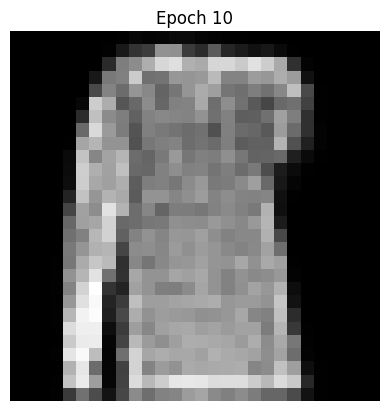

235/235 ━━━━━━━━━━━━━━━━━━━━ 27s 114ms/step - d_loss: 0.6587 - g_loss: 0.7341
Epoch 11/30
235/235 ━━━━━━━━━━━━━━━━━━━━ 26s 112ms/step - d_loss: 0.6584 - g_loss: 0.7207
Epoch 12/30
235/235 ━━━━━━━━━━━━━━━━━━━━ 27s 113ms/step - d_loss: 0.6617 - g_loss: 0.7243
Epoch 13/30
235/235 ━━━━━━━━━━━━━━━━━━━━ 26s 112ms/step - d_loss: 0.6615 - g_loss: 0.7249
Epoch 14/30
235/235 ━━━━━━━━━━━━━━━━━━━━ 27s 114ms/step - d_loss: 0.6609 - g_loss: 0.7213
Epoch 15/30
235/235 ━━━━━━━━━━━━━━━━━━━━ 0s 113ms/step - d_loss: 0.6593 - g_loss: 0.8003

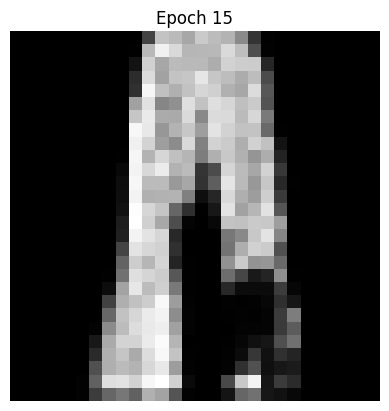

235/235 ━━━━━━━━━━━━━━━━━━━━ 27s 113ms/step - d_loss: 0.6591 - g_loss: 0.8070
Epoch 16/30
235/235 ━━━━━━━━━━━━━━━━━━━━ 26s 111ms/step - d_loss: 0.6580 - g_loss: 0.7148
Epoch 17/30
235/235 ━━━━━━━━━━━━━━━━━━━━ 26s 111ms/step - d_loss: 0.6595 - g_loss: 0.7239
Epoch 18/30
235/235 ━━━━━━━━━━━━━━━━━━━━ 26s 111ms/step - d_loss: 0.6599 - g_loss: 0.7220
Epoch 19/30
235/235 ━━━━━━━━━━━━━━━━━━━━ 27s 113ms/step - d_loss: 0.6613 - g_loss: 0.7266
Epoch 20/30
235/235 ━━━━━━━━━━━━━━━━━━━━ 0s 111ms/step - d_loss: 0.6623 - g_loss: 0.7277

\nSaved generator model at epoch 20


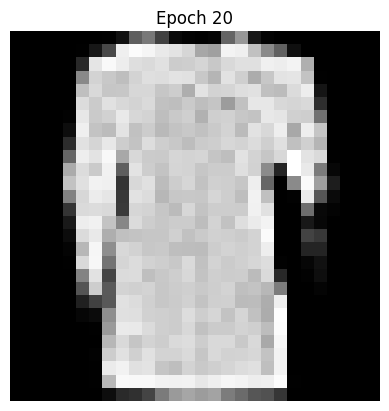

235/235 ━━━━━━━━━━━━━━━━━━━━ 26s 112ms/step - d_loss: 0.6629 - g_loss: 0.7289
Epoch 21/30
235/235 ━━━━━━━━━━━━━━━━━━━━ 26s 112ms/step - d_loss: 0.6609 - g_loss: 0.7304
Epoch 22/30
235/235 ━━━━━━━━━━━━━━━━━━━━ 26s 111ms/step - d_loss: 0.6610 - g_loss: 0.7315
Epoch 23/30
235/235 ━━━━━━━━━━━━━━━━━━━━ 26s 113ms/step - d_loss: 0.6563 - g_loss: 0.8200
Epoch 24/30
235/235 ━━━━━━━━━━━━━━━━━━━━ 27s 113ms/step - d_loss: 0.6602 - g_loss: 0.7259
Epoch 25/30
235/235 ━━━━━━━━━━━━━━━━━━━━ 0s 113ms/step - d_loss: 0.6586 - g_loss: 0.7148

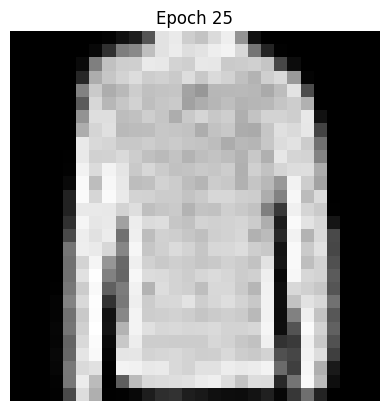

235/235 ━━━━━━━━━━━━━━━━━━━━ 27s 113ms/step - d_loss: 0.6589 - g_loss: 0.7195
Epoch 26/30
235/235 ━━━━━━━━━━━━━━━━━━━━ 26s 112ms/step - d_loss: 0.6589 - g_loss: 0.7266
Epoch 27/30
235/235 ━━━━━━━━━━━━━━━━━━━━ 26s 112ms/step - d_loss: 0.6611 - g_loss: 0.7355
Epoch 28/30
235/235 ━━━━━━━━━━━━━━━━━━━━ 26s 111ms/step - d_loss: 0.6585 - g_loss: 0.7294
Epoch 29/30
235/235 ━━━━━━━━━━━━━━━━━━━━ 26s 112ms/step - d_loss: 0.6541 - g_loss: 0.8129
Epoch 30/30
235/235 ━━━━━━━━━━━━━━━━━━━━ 0s 112ms/step - d_loss: 0.6604 - g_loss: 0.7509

\nSaved generator model at epoch 30


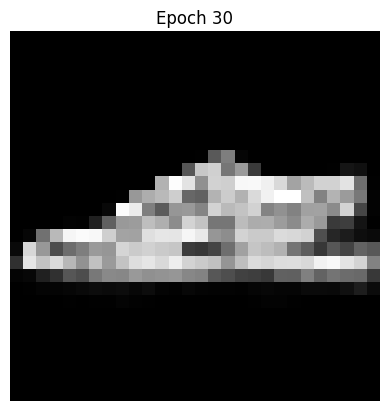

235/235 ━━━━━━━━━━━━━━━━━━━━ 26s 113ms/step - d_loss: 0.6596 - g_loss: 0.7321
Training complete and final model saved successfully.


In [ ]:
discriminator = build_discriminator()
generator = build_generator(LATENT_DIM)

gan = DCGAN(discriminator=discriminator, generator=generator, latent_dim=LATENT_DIM)

gan.compile(
    d_optimizer=tf.keras.optimizers.Adam(learning_rate=0.0002, beta_1=0.5),
    g_optimizer=tf.keras.optimizers.Adam(learning_rate=0.0002, beta_1=0.5),
    loss_fn=tf.keras.losses.BinaryCrossentropy(),
)

class SaveModelAndImages(callbacks.Callback):
    def on_epoch_end(self, epoch, logs=None):
        if (epoch + 1) % 10 == 0:
            os.makedirs("models", exist_ok=True)
            self.model.generator.save(f"models/generator_epoch_{epoch+1}.h5")
            print(f"\\nSaved generator model at epoch {epoch+1}")

        if (epoch + 1) % 5 == 0:
            noise = tf.random.normal([1, LATENT_DIM])
            gen_image = self.model.generator(noise, training=False)
            plt.imshow(gen_image[0, :, :, 0] * 127.5 + 127.5, cmap="gray")
            plt.title(f"Epoch {epoch+1}")
            plt.axis("off")
            plt.show()


EPOCHS = 30
gan.fit(dataset, epochs=EPOCHS, callbacks=[SaveModelAndImages()])

generator.save("models/final_generator_model.keras")
print("Training complete and final model saved successfully.")


Predictions


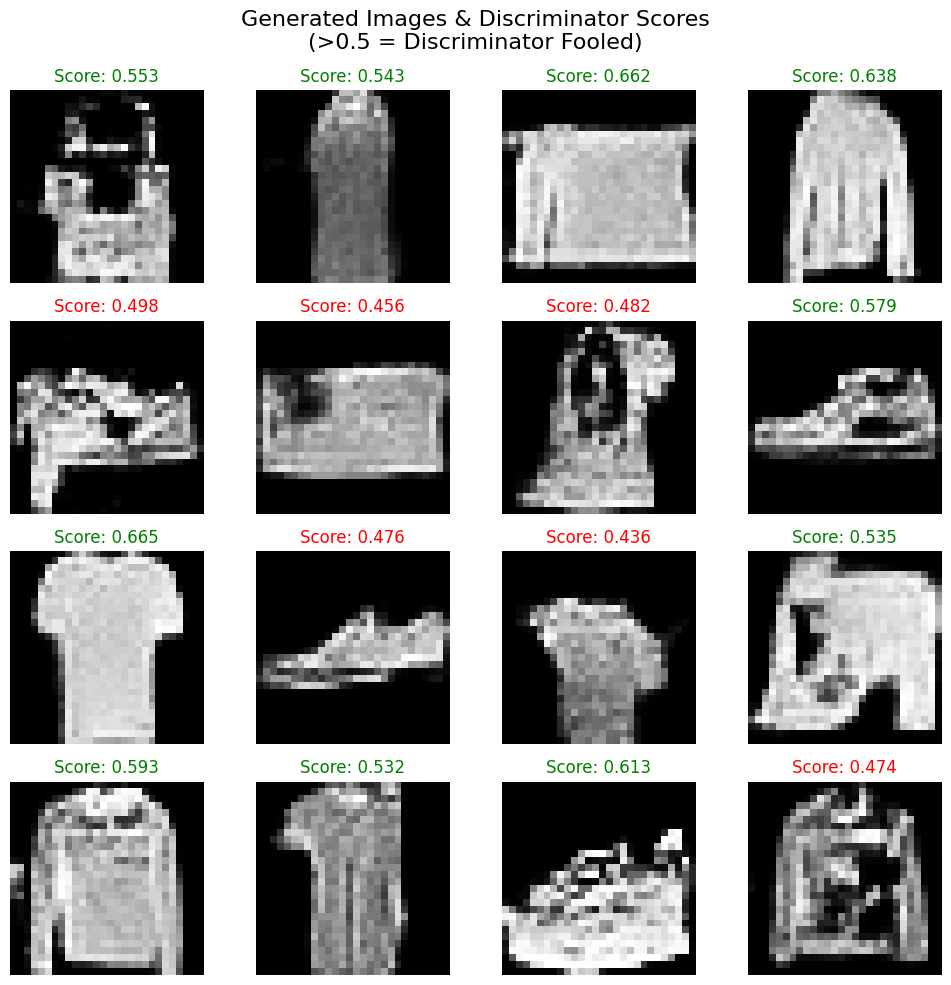

In [14]:
test_and_predict(generator, discriminator, LATENT_DIM)